<p style="font-family:Bookman Old Style;font-size:27px">Import libraries</p>

In [18]:
import cv2
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Compute DFT components</p>

In [19]:
def dft_transform_and_reconstruct(img_gray):
    freq_img = np.fft.fft2(img_gray)
    shift_img = np.fft.fftshift(freq_img)

    magnitude_img = 20 * (np.log10(np.abs(shift_img)) + 0.01)
    phase_img = np.angle(shift_img)
    
    real_freq_img = np.fft.ifft2(freq_img).real
    
    return magnitude_img, phase_img, real_freq_img, freq_img

<p style="font-family:Bookman Old Style;font-size:27px">Apply DFT on first image</p>

In [20]:
img1 = rgb2gray(imread('../images-videos/house.jpg'))
magnitude_img_1, phase_img_1, real_freq_img_1,_ = dft_transform_and_reconstruct(img1)

<p style="font-family:Bookman Old Style;font-size:27px">Plotting the results</p>

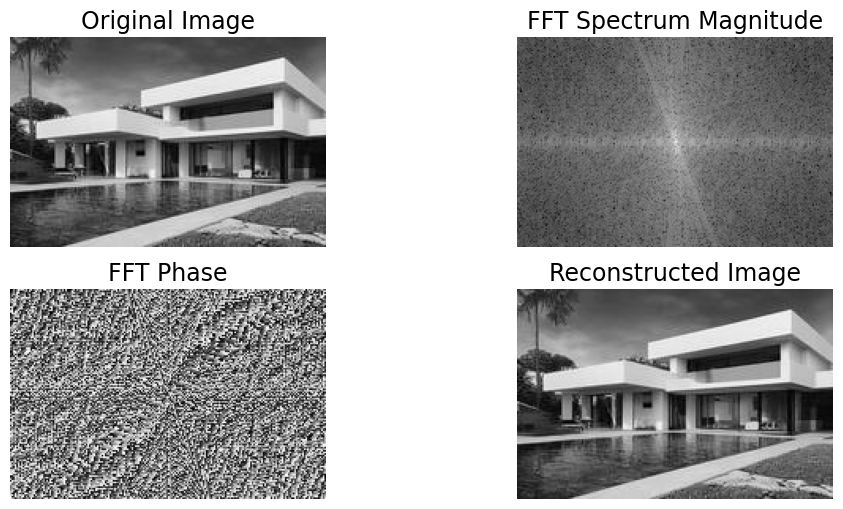

In [21]:
plt.figure(1, figsize=(12, 6))

plt.subplot(221)
plt.imshow(img1, cmap='gray')
plt.title('Original Image', size=17)
plt.axis('off')

plt.subplot(222)
plt.imshow(magnitude_img_1, cmap='gray')
plt.title('FFT Spectrum Magnitude', size=17)
plt.axis('off')

plt.subplot(223)
plt.imshow(phase_img_1, cmap='gray')
plt.title('FFT Phase', size=17)
plt.axis('off')

plt.subplot(224)
plt.imshow(real_freq_img_1, cmap='gray')
plt.title('Reconstructed Image', size=17)
plt.axis('off')
plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Apply DFT on second image</p>

In [22]:
img2 = rgb2gray(imread('../images-videos/h12.jpg'))
magnitude_img_2, phase_img_2, real_freq_img_2, _= dft_transform_and_reconstruct(img2)

<p style="font-family:Bookman Old Style;font-size:27px">Plotting the results</p>

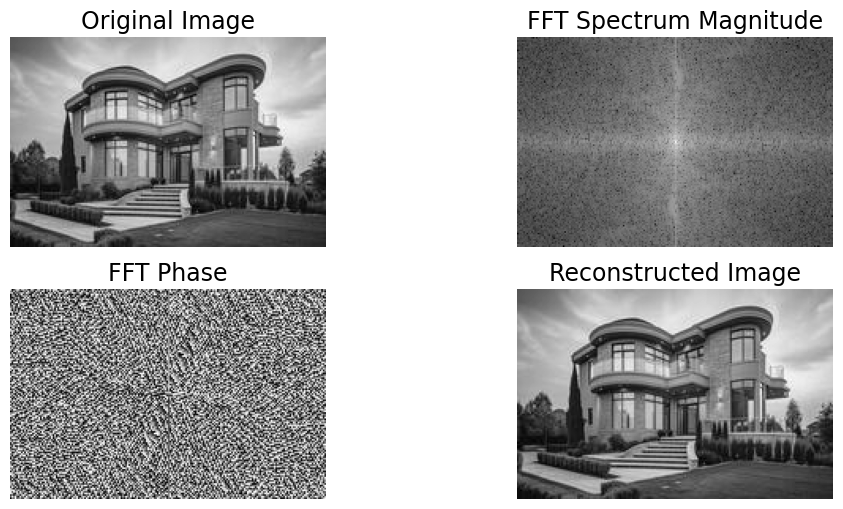

In [23]:
plt.figure(2, figsize=(12, 6))

plt.subplot(221)
plt.imshow(img2, cmap='gray')
plt.title('Original Image', size=17)
plt.axis('off')

plt.subplot(222)
plt.imshow(magnitude_img_2, cmap='gray')
plt.title('FFT Spectrum Magnitude', size=17)
plt.axis('off')

plt.subplot(223)
plt.imshow(phase_img_2, cmap='gray')
plt.title('FFT Phase', size=17)
plt.axis('off')

plt.subplot(224)
plt.imshow(real_freq_img_2, cmap='gray')
plt.title('Reconstructed Image', size=17)
plt.axis('off')
plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Loading images for combine real and imaginary parts</p>

In [24]:
img1 = rgb2gray(imread('../images-videos/house.jpg'))
img2 = rgb2gray(imread('../images-videos/h12.jpg'))

<p style="font-family:Bookman Old Style;font-size:27px">Creating hybrid images</p>

In [25]:
magnitude_img_1, phase_img_1, real_freq_img_1, freq1 = dft_transform_and_reconstruct(img1)
magnitude_img_2, phase_img_2, real_freq_img_2, freq2 = dft_transform_and_reconstruct(img2)

new_img1 = np.fft.ifft2(np.vectorize(complex)(freq1.real, freq2.imag)).real
new_img2 = np.fft.ifft2(np.vectorize(complex)(freq2.real, freq1.imag)).real

<p style="font-family:Bookman Old Style;font-size:27px">Plotting the results</p>

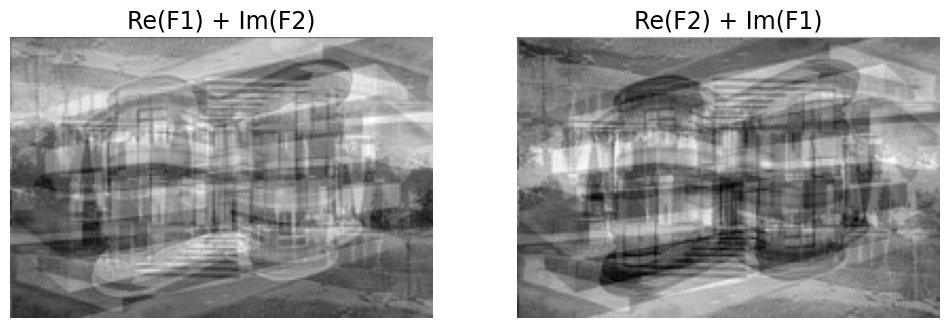

In [26]:
plt.figure(1, figsize=(12, 8))

plt.subplot(121)
plt.imshow(new_img1, cmap='gray')
plt.title('Re(F1) + Im(F2)', size=17)
plt.axis('off')

plt.subplot(122)
plt.imshow(new_img2, cmap='gray')
plt.title('Re(F2) + Im(F1)', size=17)
plt.axis('off')

plt.show()